# Spotify Cohort Analysis

# In case of Conda, we need to use pd.read_csv(r"path") // Here path is file path, which can come from right clicking the file.
# Else we use the BAU filename

## Data Loading & Cleaning

In [1]:
import pandas as pd
import numpy as np

df = pd.read_csv(r"D:\OneDrive\Desktop\rolling_stones_spotify.csv")

df.drop_duplicates(inplace=True)
df.fillna(method='ffill', inplace=True)

df['release_date'] = pd.to_datetime(df['release_date'], errors='coerce')
df['year'] = df['release_date'].dt.year

df.head()

C:\Users\jared\AppData\Local\Temp\ipykernel_11256\1185639951.py:7: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df.fillna(method='ffill', inplace=True)


,Unnamed: 0,name,album,release_date,track_number,id,uri,acousticness,danceability,energy,instrumentalness,liveness,loudness,speechiness,tempo,valence,popularity,duration_ms,year
0,0,Concert Intro Music - Live,Licked Live In NYC,2022-06-10,1,2IEkywLJ4ykbhi1yRQvmsT,spotify:track:2IEkywLJ4ykbhi1yRQvmsT,0.0824,0.463,0.993,0.996000,0.932,-12.913,0.1100,118.001,0.0302,33,48640,2022
1,1,Street Fighting Man - Live,Licked Live In NYC,2022-06-10,2,6GVgVJBKkGJoRfarYRvGTU,spotify:track:6GVgVJBKkGJoRfarYRvGTU,0.4370,0.326,0.965,0.233000,0.961,-4.803,0.0759,131.455,0.3180,34,253173,2022
2,2,Start Me Up - Live,Licked Live In NYC,2022-06-10,3,1Lu761pZ0dBTGpzxaQoZNW,spotify:track:1Lu761pZ0dBTGpzxaQoZNW,0.4160,0.386,0.969,0.400000,0.956,-4.936,0.1150,130.066,0.3130,34,263160,2022
3,3,If You Can't Rock Me - Live,Licked Live In NYC,2022-06-10,4,1agTQzOTUnGNggyckEqiDH,spotify:track:1agTQzOTUnGNggyckEqiDH,0.5670,0.369,0.985,0.000107,0.895,-5.535,0.1930,132.994,0.1470,32,305880,2022
4,4,Don’t Stop - Live,Licked Live In NYC,2022-06-10,5,7piGJR8YndQBQWVXv6KtQw,spotify:track:7piGJR8YndQBQWVXv6KtQw,0.4000,0.303,0.969,0.055900,0.966,-5.098,0.0930,130.533,0.2060,32,305106,2022


## Exploratory Data Analysis (EDA)

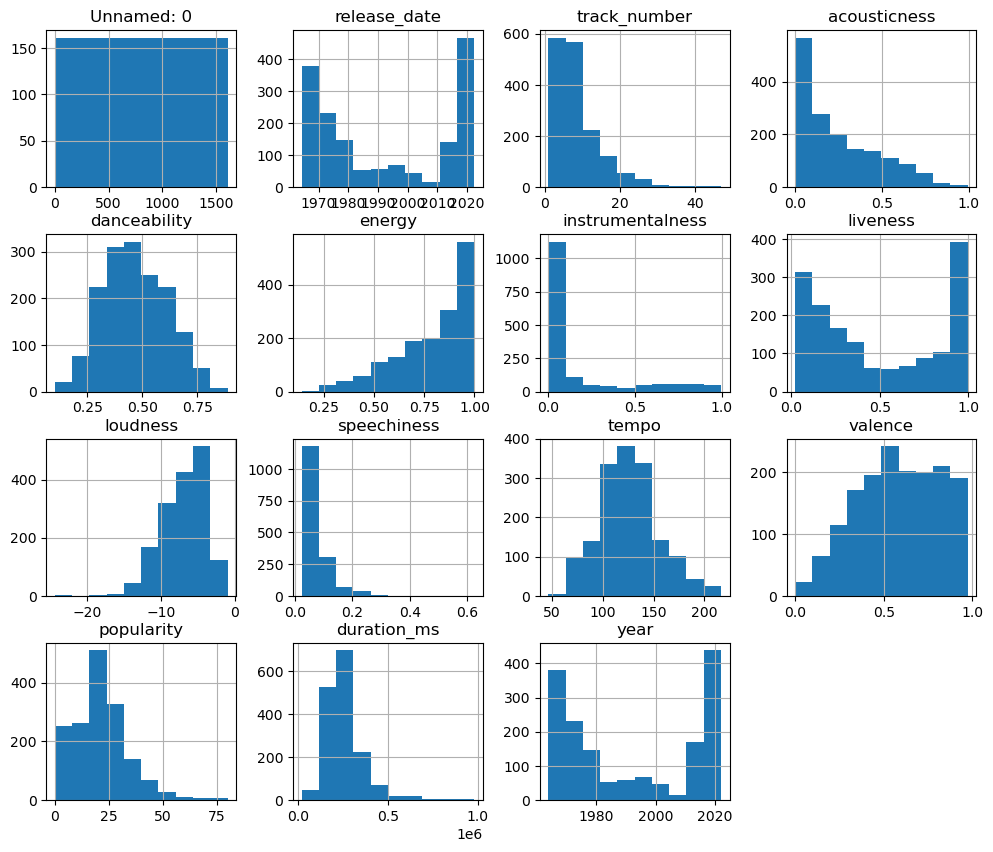

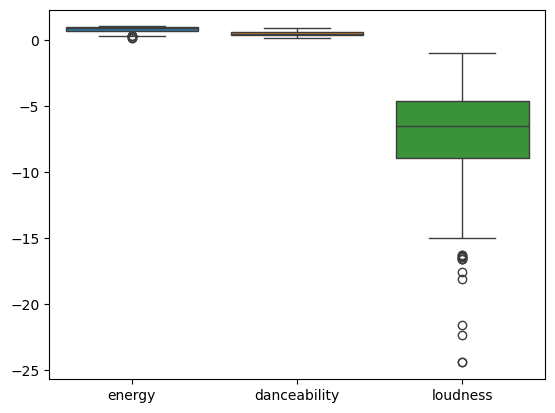

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns

# Distribution plots
df.hist(figsize=(12,10))
plt.show()

# Boxplots for outliers
sns.boxplot(data=df[['energy','danceability','loudness']])
plt.show()

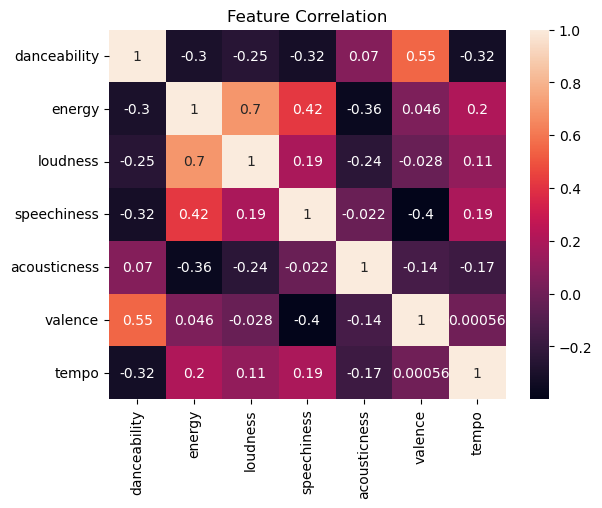

In [3]:
# Correlation Heatmap
features_corr = ['danceability','energy','loudness','speechiness','acousticness','valence','tempo']

sns.heatmap(df[features_corr].corr(), annot=True)
plt.title("Feature Correlation")
plt.show()

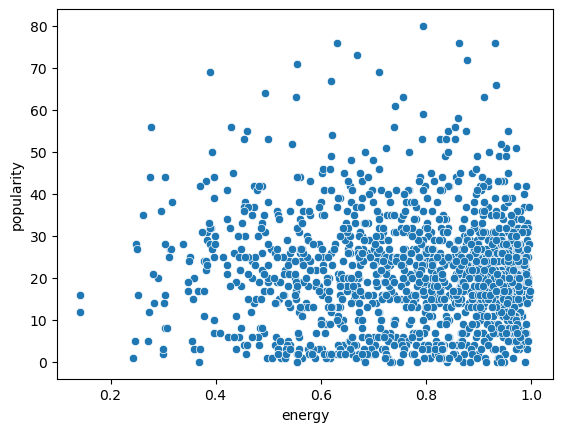

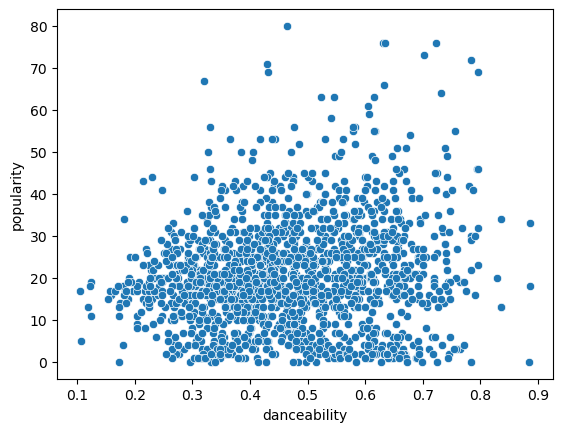

In [4]:
# Popularity relationships
sns.scatterplot(x='energy', y='popularity', data=df)
plt.show()

sns.scatterplot(x='danceability', y='popularity', data=df)
plt.show()

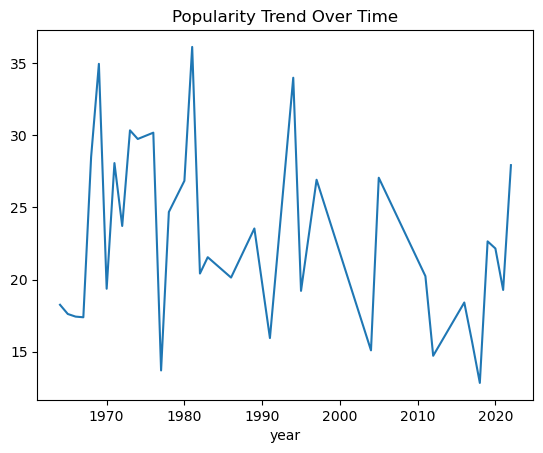

In [5]:
# Popularity over time
yearly_popularity = df.groupby('year')['popularity'].mean()

yearly_popularity.plot()
plt.title("Popularity Trend Over Time")
plt.show()

## Feature Scaling

In [7]:
from sklearn.preprocessing import StandardScaler

features = ['acousticness','danceability','energy','instrumentalness',
            'liveness','loudness','speechiness','tempo','valence','duration_ms']

scaler = StandardScaler()
scaled_data = scaler.fit_transform(df[features])

## Elbow Method

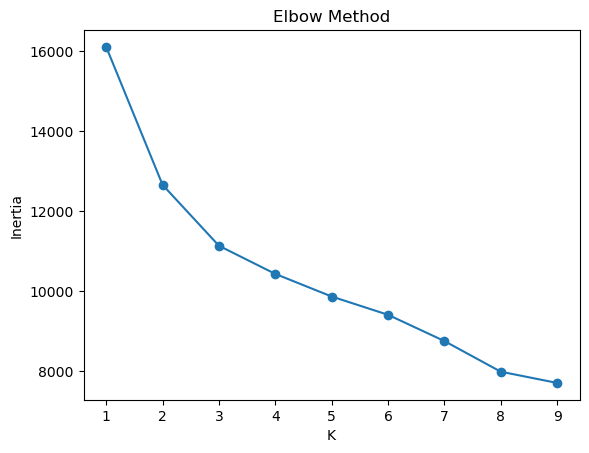

In [8]:
from sklearn.cluster import KMeans

inertia = []
K = range(1,10)

for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(scaled_data)
    inertia.append(kmeans.inertia_)

plt.plot(K, inertia, marker='o')
plt.title("Elbow Method")
plt.xlabel("K")
plt.ylabel("Inertia")
plt.show()

## Silhouette Score

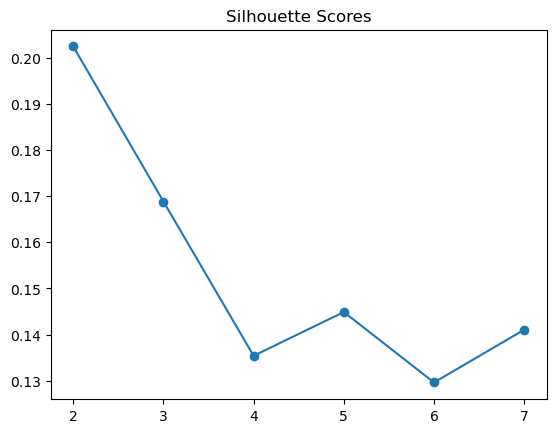

In [9]:
from sklearn.metrics import silhouette_score

scores = []
for k in range(2,8):
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(scaled_data)
    scores.append(silhouette_score(scaled_data, labels))

plt.plot(range(2,8), scores, marker='o')
plt.title("Silhouette Scores")
plt.show()

## PCA Visualization

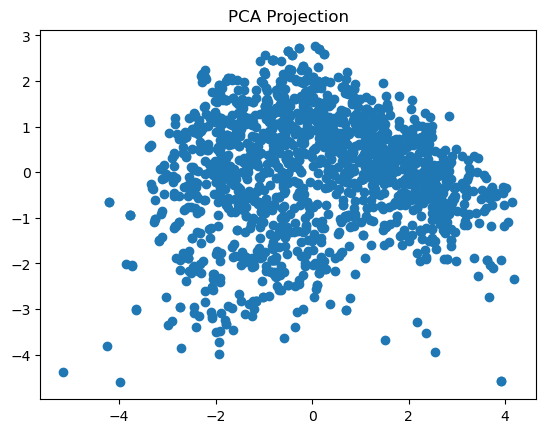

In [10]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
pca_data = pca.fit_transform(scaled_data)

plt.scatter(pca_data[:,0], pca_data[:,1])
plt.title("PCA Projection")
plt.show()

## Final Clustering

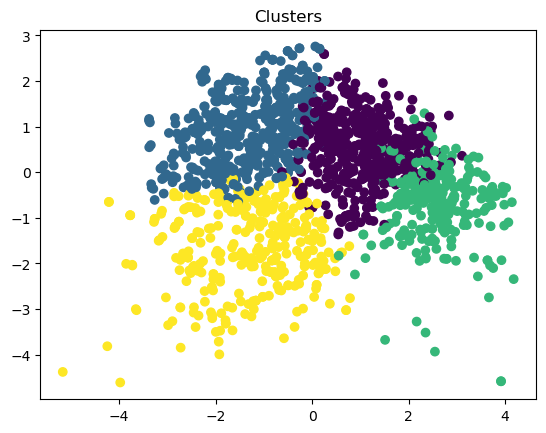

In [11]:
kmeans = KMeans(n_clusters=4, random_state=42)
df['cluster'] = kmeans.fit_predict(scaled_data)

plt.scatter(pca_data[:,0], pca_data[:,1], c=df['cluster'])
plt.title("Clusters")
plt.show()

## DBSCAN

In [12]:
from sklearn.cluster import DBSCAN

dbscan = DBSCAN(eps=1.5, min_samples=5)
df['dbscan_cluster'] = dbscan.fit_predict(scaled_data)

df['dbscan_cluster'].value_counts()

dbscan_cluster
 0     1150
-1      355
 9       27
 2       25
 3        9
 5        7
 8        6
 6        6
 7        5
 10       5
 1        5
 4        5
 11       5
Name: count, dtype: int64

## Hierarchical Clustering

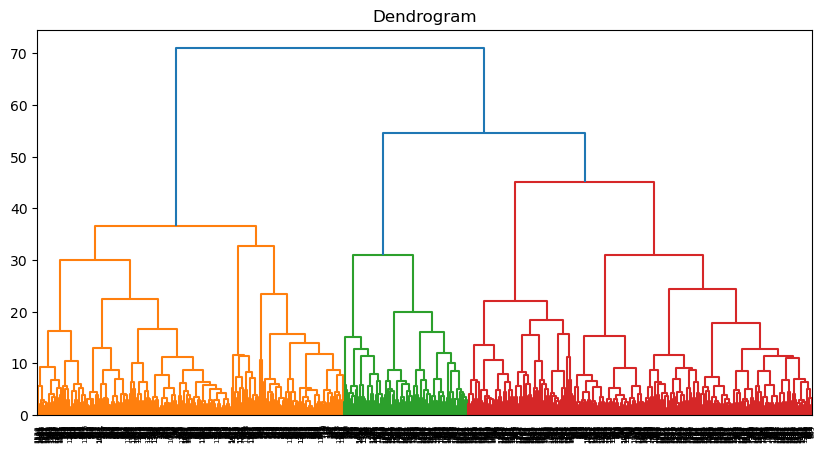

In [13]:
from scipy.cluster.hierarchy import dendrogram, linkage

linked = linkage(scaled_data, method='ward')

plt.figure(figsize=(10,5))
dendrogram(linked)
plt.title("Dendrogram")
plt.show()

## Conclusion
- EDA revealed key patterns in song features and popularity  
- Optimal clusters identified using Elbow and Silhouette  
- Multiple clustering techniques applied for robustness  
- Songs grouped into meaningful cohorts for recommendation systems  
